In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Dropout
import matplotlib.pyplot as plt
from math import sqrt
from sklearn import metrics
print("Import Complete")

Import Complete


In [8]:
# Define the ticker symbol
ticker_symbol = 'HINDUNILVR.NS'  

# Set the start and end dates for the historical data
start_date = '2020-01-01'
end_date = '2024-03-03'

# Fetch historical data from Yahoo Finance
df = yf.download(ticker_symbol, start=start_date, end=end_date)

# Reset the index to make 'Date' a column
df.reset_index(inplace=True)

# Preprocessing data
sc = MinMaxScaler(feature_range=(0, 1))
dataset_scaled = sc.fit_transform(df['Close'].values.reshape(-1,1))

# Creating training data
X_train = []
y_train = []
for i in range(60, len(dataset_scaled)):
    X_train.append(dataset_scaled[i-60:i, 0])
    y_train.append(dataset_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Creating the GRU model
model = Sequential()
model.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(GRU(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(GRU(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(GRU(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))

# Compiling the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Training the model
model.fit(X_train, y_train, epochs=50, batch_size=32)

# Predicting the stock prices
inputs = dataset_scaled[len(dataset_scaled) - len(df):]
X_test = []
for i in range(60, len(inputs)):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = model.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)


[*********************100%%**********************]  1 of 1 completed


Epoch 1/50
31/31 [==============================] - 6s 57ms/step - loss: 0.0547
Epoch 2/50
31/31 [==============================] - 2s 56ms/step - loss: 0.0118
Epoch 3/50
31/31 [==============================] - 2s 55ms/step - loss: 0.0100
Epoch 4/50
31/31 [==============================] - 2s 67ms/step - loss: 0.0088
Epoch 5/50
31/31 [==============================] - 2s 67ms/step - loss: 0.0078
Epoch 6/50
31/31 [==============================] - 2s 67ms/step - loss: 0.0078
Epoch 7/50
31/31 [==============================] - 2s 66ms/step - loss: 0.0070
Epoch 8/50
31/31 [==============================] - 2s 67ms/step - loss: 0.0061
Epoch 9/50
31/31 [==============================] - 2s 69ms/step - loss: 0.0065
Epoch 10/50
31/31 [==============================] - 2s 80ms/step - loss: 0.0068
Epoch 11/50
31/31 [==============================] - 2s 69ms/step - loss: 0.0056
Epoch 12/50
31/31 [==============================] - 2s 68ms/step - loss: 0.0060
Epoch 13/50
31/31 [==================

In [14]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

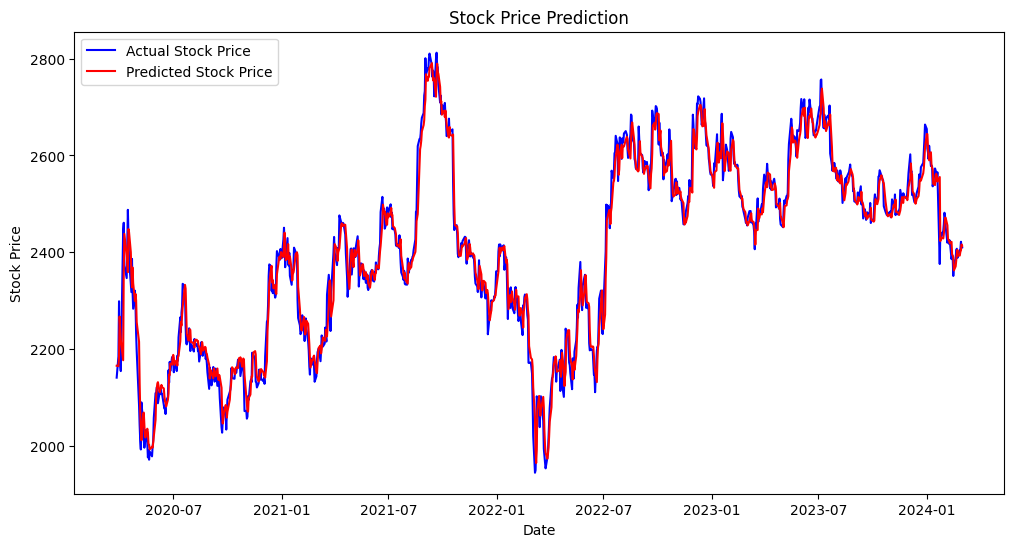

Root Mean Squared Error (RMSE): 34.39936020754397
Mean Absolute Error (MAE): 24.759868790064104
R-squared (R2) Score: 0.9689068889969463


In [15]:
# Visualizing the results
plt.figure(figsize=(12, 6))
plt.plot(df['Date'][-len(predicted_stock_price):], df['Close'][-len(predicted_stock_price):], color='blue', label='Actual Stock Price')
plt.plot(df['Date'][-len(predicted_stock_price):], predicted_stock_price, color='red', label='Predicted Stock Price')
plt.title('Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

# Calculating the error
rmse = sqrt(mean_squared_error(df['Close'][-len(predicted_stock_price):], predicted_stock_price))
mae = mean_absolute_error(df['Close'][-len(predicted_stock_price):], predicted_stock_price)
r2 = r2_score(df['Close'][-len(predicted_stock_price):], predicted_stock_price)

print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2) Score:", r2)


In [26]:
# Number of days to predict into the future
days_to_predict = 10

# Predicting the stock prices for the next 'days_to_predict' days
future_predictions = []
last_sequence = dataset_scaled[-60:]  # Taking the last sequence of 60 days as input for prediction

for _ in range(days_to_predict):
    # Reshaping the input sequence for prediction
    X_pred = np.reshape(last_sequence, (1, last_sequence.shape[0], 1))
    # Predicting the next day's stock price
    next_prediction = model.predict(X_pred)
    future_predictions.append(next_prediction[0, 0])
    # Update the input sequence for the next prediction
    last_sequence = np.append(last_sequence[1:], next_prediction)

# Scaling back the predicted prices to original scale
future_predictions = np.array(future_predictions).reshape(-1, 1)
predicted_stock_price_future = sc.inverse_transform(future_predictions)

# Generating dates for the future predictions
last_date = df['Date'].iloc[-1]
future_dates = pd.date_range(start=last_date, periods=days_to_predict+1)[1:]

# Creating a DataFrame for the future predictions
future_df = pd.DataFrame({'Date': future_dates, 'Predicted Stock Price': predicted_stock_price_future.flatten()})

print(future_df)


1/1 [==============================] - 0s 20ms/step
        Date  Predicted Stock Price
0 2024-03-02            2409.939941
1 2024-03-03            2409.261963
2 2024-03-04            2408.715332
3 2024-03-05            2408.181396
4 2024-03-06            2407.654541
5 2024-03-07            2407.135986
6 2024-03-08            2406.626709
7 2024-03-09            2406.127197
8 2024-03-10            2405.639160
9 2024-03-11            2405.162354


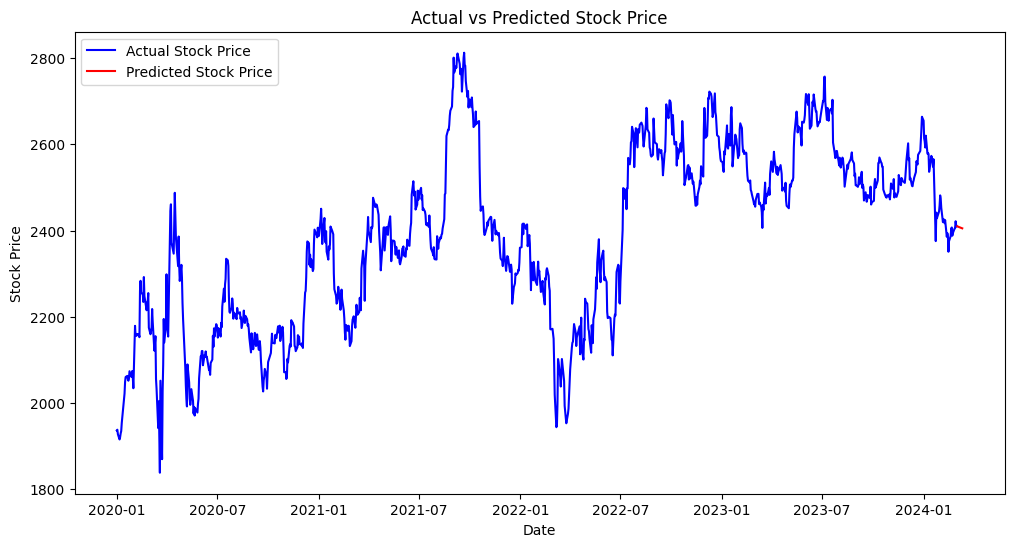

In [27]:
# Concatenating actual and future predicted data for visualization
combined_df = pd.concat([df[['Date', 'Close']], future_df.set_index('Date')], axis=0)

# Plotting actual and predicted stock prices
plt.figure(figsize=(12, 6))
plt.plot(combined_df['Date'], combined_df['Close'], color='blue', label='Actual Stock Price')
plt.plot(future_df['Date'], future_df['Predicted Stock Price'], color='red', label='Predicted Stock Price')
plt.title('Actual vs Predicted Stock Price')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()


[*********************100%%**********************]  1 of 1 completed


14/14 [==============================] - 1s 14ms/step


[*********************100%%**********************]  1 of 1 completed


14/14 [==============================] - 1s 15ms/step


[*********************100%%**********************]  1 of 1 completed


14/14 [==============================] - 1s 13ms/step


[*********************100%%**********************]  1 of 1 completed


14/14 [==============================] - 1s 15ms/step


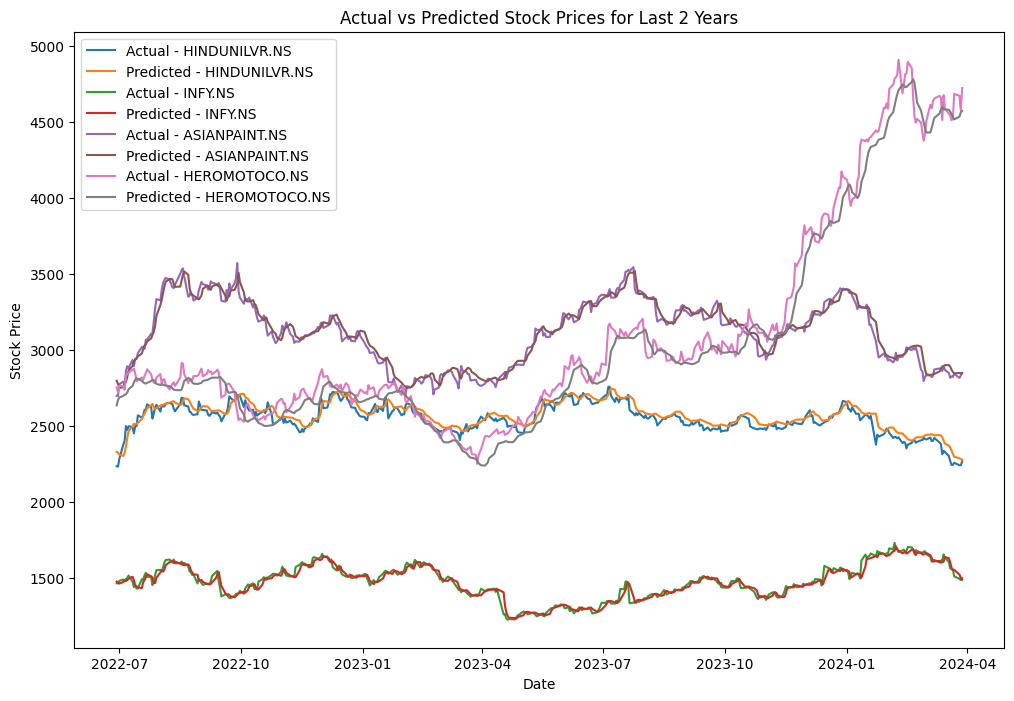

In [29]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

# Define the list of ticker symbols
ticker_symbols = ['HINDUNILVR.NS', 'INFY.NS', 'ASIANPAINT.NS', 'HEROMOTOCO.NS']

# Set the start and end dates for the historical data
start_date = '2022-04-01'  # Last 2 years
end_date = '2024-04-01'

# Function to train and predict using GRU model
def train_predict_gru(ticker_symbol):
    # Fetch historical data from Yahoo Finance
    df = yf.download(ticker_symbol, start=start_date, end=end_date)
    df.reset_index(inplace=True)

    # Preprocessing data
    sc = MinMaxScaler(feature_range=(0, 1))
    dataset_scaled = sc.fit_transform(df['Close'].values.reshape(-1,1))

    # Creating training data
    X_train = []
    y_train = []
    for i in range(60, len(dataset_scaled)):
        X_train.append(dataset_scaled[i-60:i, 0])
        y_train.append(dataset_scaled[i, 0])
    X_train, y_train = np.array(X_train), np.array(y_train)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

    # Creating the GRU model
    model = Sequential()
    model.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(GRU(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(GRU(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(GRU(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))

    # Compiling the model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Training the model
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

    # Predicting the stock prices
    inputs = dataset_scaled[-len(df):]
    X_test = []
    for i in range(60, len(inputs)):
        X_test.append(inputs[i-60:i, 0])
    X_test = np.array(X_test)
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    predicted_stock_price = model.predict(X_test)
    predicted_stock_price = sc.inverse_transform(predicted_stock_price)

    # Calculating performance metrics
    rmse = sqrt(mean_squared_error(df['Close'][-len(predicted_stock_price):], predicted_stock_price))
    mae = mean_absolute_error(df['Close'][-len(predicted_stock_price):], predicted_stock_price)
    r2 = r2_score(df['Close'][-len(predicted_stock_price):], predicted_stock_price)

    return df['Date'][-len(predicted_stock_price):], df['Close'][-len(predicted_stock_price):], predicted_stock_price, rmse, mae, r2

# Plotting performance for each stock
plt.figure(figsize=(12, 8))

for ticker_symbol in ticker_symbols:
    dates, actual_prices, predicted_prices, rmse, mae, r2 = train_predict_gru(ticker_symbol)
    plt.plot(dates, actual_prices, label=f'Actual - {ticker_symbol}')
    plt.plot(dates, predicted_prices, label=f'Predicted - {ticker_symbol}')

plt.title('Actual vs Predicted Stock Prices for Last 2 Years')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()


In [30]:
import pandas as pd

# Create a DataFrame to store MSE for each stock
mse_data = []

for ticker_symbol in ticker_symbols:
    _, _, _, rmse, _, _ = train_predict_gru(ticker_symbol)
    mse_data.append({'Stock': ticker_symbol, 'RMSE': rmse})

mse_df = pd.DataFrame(mse_data)

print("Mean Squared Error (RMSE) for each stock:")
print(mse_df)


[*********************100%%**********************]  1 of 1 completed


14/14 [==============================] - 1s 16ms/step


[*********************100%%**********************]  1 of 1 completed


14/14 [==============================] - 1s 15ms/step


[*********************100%%**********************]  1 of 1 completed


14/14 [==============================] - 1s 13ms/step


[*********************100%%**********************]  1 of 1 completed


14/14 [==============================] - 1s 14ms/step
Mean Squared Error (RMSE) for each stock:
           Stock        RMSE
0  HINDUNILVR.NS   37.450395
1        INFY.NS   25.154215
2  ASIANPAINT.NS   44.801889
3  HEROMOTOCO.NS  105.153543
